In [1]:
import numpy as np
import matplotlib.pyplot as plt



In [2]:
LZdata = np.genfromtxt('../data/exps/LZ2025/WS2024_data_hist_data.txt', skip_header=1, delimiter=' ')

In [3]:
# Assuming your loaded array is called 'data'
bin_centers = LZdata[:, 0]   # column 1: bin centers (or edges)
heights = LZdata[:, 1]       # column 2: counts/density

# If column 1 is bin CENTERS, you need the width:
# Option A: Assume uniform width from spacing
bin_width = bin_centers[1] - bin_centers[0]  # if 

In [4]:
LZ_bkg_fit = np.genfromtxt('../data/exps/LZ2025/BKG_FIT_WS2024.csv', delimiter=',')

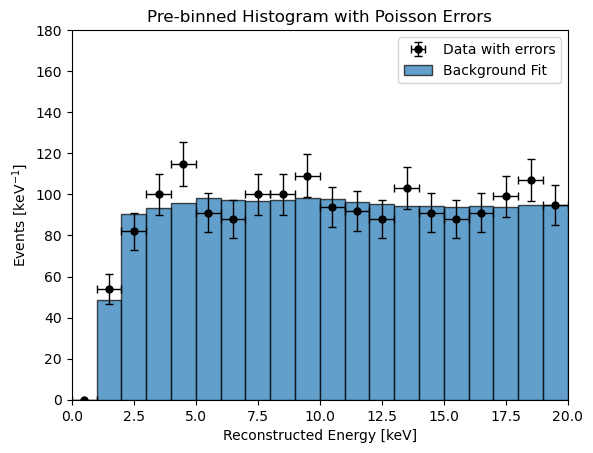

In [5]:
y_err = np.sqrt(heights)

# X-error: half bin width on each side (so bars span the full bin)
x_err = bin_width / 2

# Plot with error bars
plt.errorbar(bin_centers, heights, 
             xerr=x_err, yerr=y_err,
             fmt='o',              # marker style (like scatter)
             capsize=3,            # cap size on error bars
             capthick=1,           # cap thickness
             elinewidth=1,         # error bar line width
             markersize=5,
             label='Data with errors',
             color='black')

# Your fit curve
plt.bar(bin_centers, LZ_bkg_fit[:, 1], width=bin_width, 
        edgecolor='black', alpha=0.7, align='center', label='Background Fit')

plt.xlabel(r'Reconstructed Energy [keV]')
plt.ylabel(r'Events [keV$^{-1}$]')
plt.ylim(0,180)
plt.xlim(0.0,20.0)
plt.title('Pre-binned Histogram with Poisson Errors')
plt.legend()
plt.show()

In [6]:
from snudd import config
from snudd.targets import Electron      # the elctron target class object
from snudd.binding import binding_xe, binding_ar    # dataclass of binding energy data for xenon and argon
#from snudd.rrpa    import rrpa_scaling  # ad-hoc rrpa scaling for bound electron
from snudd.models  import GeneralNSI    # Generic NSI model
from snudd.targets import Nucleus       # Still need a nucleus to be declared

In [7]:
Xe_nucleus = Nucleus(54, 132, mass=131.9041535 * config.u) # only do one isotope for this example 


In [8]:
SM_matrix = np.array([[0, 0, 0],
                      [0, 0, 0],
                      [0, 0, 0]])

SM_eta = 0
SM_phi = 0

sm_model = GeneralNSI(SM_matrix, SM_eta, SM_phi)

In [9]:
from snudd.resolution import Resolution, Convolver # deals with the resolution effects on the rate


In [10]:
E_Rs = np.logspace(-2, 2, 1000) / 1e6  # Recoil energy in GeV, needed for the convolution to be broader than the bin considered


In [11]:
from snudd.efficiencies import efficiency_lz_er_WS24
from snudd.resolution   import res_lz_er ## not sure if this should be updated 



In [12]:
Xe_electron = Electron(Xe_nucleus, binding_xe) 
Xe_electron.update_model(sm_model)
Xe_electron.prepare_density()

sm_spec_xe = Xe_electron.spectrum(E_Rs) 

def counts_lz_ER(signal, E_Rs, E1, E2):
    exposure = 3.3 # in tn yr-1
    convolution_lz_sig= Convolver(E_Rs, signal , efficiency_lz_er_WS24, res_lz_er)
    
    return convolution_lz_sig.convolved_binned_rate(E1, E2)*exposure



In [13]:
counts_sm = [
    (counts_lz_ER(
        sm_spec_xe,
        E_Rs,
        (bc - bin_width / 2) * 1e-6,
        (bc + bin_width / 2) * 1e-6
    )).real
    for bc in bin_centers
]

/home/andrew/Documents/Tools/SNuDD/snudd/resolution.py:121: UserWarning: Minimum of supplied recoil energy (0.0) is less than minimum of supplied E_prime (1e-08). Convolution may not be accurate.
  warnings.warn(f"Minimum of supplied recoil energy ({np.min(E_R)}) is less than "


In [14]:
sum(counts_sm)

162.99029673656923